# Langchain StateGraph

## LangGraph对话

这个使用了简单的消息合并，langchain中应该使用
```python
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[List, add_messages]
```

In [9]:
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, END
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage
import operator

# 1. 定义状态 (The State)
# 使用 add_messages 来处理消息的追加，而不是覆盖
class AgentState(TypedDict):
    # operator.add 意味着新消息会 append 到列表里，而不是替换旧列表
    messages: Annotated[List, operator.add]

# 2. 定义节点 (Nodes)
llm = ChatOllama(model="gemma3:4b")

def chatbot_node(state: AgentState):
    print("--- 🤖 模型思考中 ---")
    messages = state["messages"]
    response = llm.invoke(messages)
    # 返回的内容会自动通过 operator.add 追加到 state["messages"]
    return {"messages": [response]}

# 3. 构建图 (Build Graph)
workflow = StateGraph(AgentState)

# 添加节点
workflow.add_node("chatbot", chatbot_node)

# 设置入口点 (从哪里开始)
workflow.set_entry_point("chatbot")

# 设置出口 (从 chatbot 出来后直接结束)
workflow.add_edge("chatbot", END)

# 4. 编译 (Compile)
app = workflow.compile()

# 5. 运行
inputs = {"messages": [HumanMessage(content="Eiffel tower is located in")]}
result = app.invoke(inputs)
  
print(f"Q: {result['messages'][0].content}")
print(f"A: {result['messages'][1].content}")

--- 🤖 模型思考中 ---
Q: Eiffel tower is located in
A: The Eiffel Tower is located in **Paris, France**. 

Specifically, it's situated on the Champ de Mars in the seventh arrondissement. 

Do you want to know anything more about it, like its history or dimensions?


## display graph

--- 流程图可视化 ---


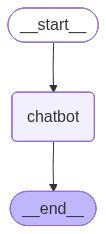

In [4]:
from IPython.display import Image, display

try:
    # 1. 获取图的 Mermaid PNG 数据
    # draw_mermaid_png() 会把图结构转换成 Mermaid 语法并生成图片
    graph_image = app.get_graph().draw_mermaid_png()

    # 2. 在 Colab 单元格中直接显示
    print("--- 流程图可视化 ---")
    display(Image(graph_image))

except Exception as e:
    print(f"生成图片失败，原因: {e}")
    # 如果图片生成失败，可以使用字符画作为备选
    print("尝试使用字符画显示:")
    try:
        app.get_graph().print_ascii()
    except:
        pass

## 多Node对话

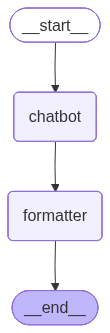


--- 开始运行 ---
--- 🤖 模型思考中 ---
--- 🔄 Upper Result ---
Final Answer: THE EIFFEL TOWER IS LOCATED IN **PARIS, FRANCE**. 

SPECIFICALLY, IT'S SITUATED ON THE CHAMP DE MARS, A LARGE PUBLIC GREENSPACE IN THE 7TH ARRONDISSEMENT. 

WOULD YOU LIKE TO KNOW ANYTHING MORE ABOUT IT, SUCH AS ITS HISTORY, DIMENSIONS, OR HOW TO VISIT?


In [93]:
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, END
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph.message import add_messages
from IPython.display import Image, display

# 1. 定义状态 (The State) - 使用新的 add_messages
class AgentState(TypedDict):
    # add_messages 是 LangGraph 专门为消息列表设计的 reducer
    # 它比 operator.add 更强大，能处理消息 ID 更新等情况
    messages: Annotated[List, add_messages]

# 2. 定义节点 (Nodes)
llm = ChatOllama(model="gemma3:4b")

# 🔥 关键修复：必须在这里重新定义 chatbot_node
# 这样它的类型注解 AgentState 才会指向上面刚刚定义的新类
def chatbot_node(state: AgentState):
    print("--- 🤖 模型思考中 ---")
    # 注意：state["messages"] 现在已经是列表了
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

# 定义第二个节点
def upper_case_node(state: AgentState):
    print("--- 🔄 Upper Result ---")
    last_message = state["messages"][-1]
    # 这里模拟把上一步的结果转成大写
    upper_content = last_message.content.upper()
    return {"messages": [AIMessage(content=upper_content)]}

# 3. 构建图 (Build Graph)
workflow = StateGraph(AgentState)

workflow.add_node("chatbot", chatbot_node)
workflow.add_node("formatter", upper_case_node)

workflow.set_entry_point("chatbot")

# 逻辑：chatbot -> formatter -> END
workflow.add_edge("chatbot", "formatter")
workflow.add_edge("formatter", END)

# 4. 编译
app = workflow.compile()

# 可视化 (可选)
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("可视化依赖未安装，跳过绘图")

# 5. 运行
print("\n--- 开始运行 ---")
inputs = {"messages": [HumanMessage(content="Eiffel tower is located in")]}
result = app.invoke(inputs)

# 打印最后一条消息（应该是大写的那条）
print(f"Final Answer: {result['messages'][-1].content}")

## Checkpointer（记忆与持久化）

In [89]:
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage
# 👇 1. 导入类型定义
from langchain_core.runnables import RunnableConfig

# 初始化记忆保存器
memory = MemorySaver()

# 编译时加入 checkpointer
app = workflow.compile(checkpointer=memory)

# 👇 2. 显式标注类型
# 告诉编辑器：放心吧，这就是一个符合规范的 RunnableConfig
config: RunnableConfig = {"configurable": {"thread_id": "session_1"}}

print("--- 第一轮 ---")
input1 = {"messages": [HumanMessage(content="我叫Xiao Ming")]}
# 现在 invoke 就不会报错了，因为 config 的类型对上了
app.invoke(input1, config=config)

print("\n--- 第二轮 ---")
input2 = {"messages": [HumanMessage(content="我叫什么名字？")]}
result = app.invoke(input2, config=config)

print(f"回复: {result['messages'][-1].content}")

--- 第一轮 ---
--- 🤖 模型思考中 ---
--- 🔄 Upper Result ---

--- 第二轮 ---
--- 🤖 模型思考中 ---
--- 🔄 Upper Result ---
回复: 你叫XIAO MING！

(NǏ JIÀO XIAO MING!) 

(TRANSLATION: YOU ARE CALLED XIAO MING!) (PROCESSED)


## 人工介入

In [92]:
# 假设我们要在 chatbot 回复之前，人工检查一下
# 我们在编译时设置 interrupt_before

app = workflow.compile(
    checkpointer=memory,
    interrupt_before=["chatbot"] # 在进入 chatbot 节点前暂停
)

config: RunnableConfig = {"configurable": {"thread_id": "session_1"}}

# 1. 触发运行
print("--- 启动工作流 ---")
app.invoke({"messages": [HumanMessage(content="帮我写一封辞职信")]}, config=config)

# 此时程序会暂停！因为遇到了 interrupt
state = app.get_state(config)
print(f"\n⏸️ 当前状态: {state.next}") # 会显示 next=('chatbot',)

print("--- 人类审核通过，继续执行 ---")

#这里的 None 表示不修改状态，直接继续
result = app.stream(None, config=config) 

# 👇 修改了这里 👇
for event in result:
    # event 的样子通常是：{'chatbot': {'messages': [AIMessage(...)]}}
    for node_name, node_value in event.items():
        print(f"\nExample 节点 '{node_name}' 完成执行:")
        
        # 提取 messages 中的内容
        if "messages" in node_value:
            # 获取最新的一条消息
            latest_message = node_value["messages"][-1]
            print(f"🤖 回复内容:\n{latest_message.content[:10]}")
            
print("\n✅ 执行完成")

--- 启动工作流 ---

⏸️ 当前状态: ('chatbot',)
--- 人类审核通过，继续执行 ---
--- 🤖 模型思考中 ---

Example 节点 'chatbot' 完成执行:
🤖 回复内容:
Okay, let’
--- 🔄 Upper Result ---

Example 节点 'formatter' 完成执行:
🤖 回复内容:
OKAY, LET’

✅ 执行完成


## 显式路由节点 模拟

**痛点**： GPT-4 可以完美理解“请根据上一步结果决定下一步是搜索还是结束”，但本地 7B/8B 小模型（如 Llama3, Qwen2.5）经常：

1. **废话多**：不只输出分类标签，还要加“好的，根据分析...”。
2. **格式乱**：JSON 经常少个括号。
3. **跟丢指令**：聊着聊着忘了自己是个路由（Router）。

**解决方案：显式路由节点 (Explicit Router Node)** 不要让 LLM 隐式决定，而是专门写一个 Node 用来做选择。

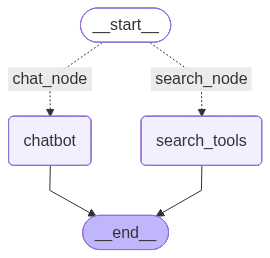

=== 测试 1: 闲聊 ===
--- 🚦 正在路由分类 ---
DEBUG: 模型原始输出 -> 'CHAT'
--- 💬 进入闲聊模式 ---

=== 测试 2: 搜索意图 ===
--- 🚦 正在路由分类 ---
DEBUG: 模型原始输出 -> 'SEARCH'
--- 🔍 进入搜索模式 ---


{'messages': [HumanMessage(content='埃菲尔铁塔在哪里？', additional_kwargs={}, response_metadata={}, id='63b67ef1-19d2-4572-8b8b-856dceabc670'),
  AIMessage(content='【搜索结果】: 埃菲尔铁塔位于法国巴黎。', additional_kwargs={}, response_metadata={}, id='274b3b73-cf02-40ca-9348-1df5f2b5ad49')]}

In [ ]:
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, END, START
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph.message import add_messages

# 1. 定义状态
class AgentState(TypedDict):
    messages: Annotated[List, add_messages]

# 2. 初始化 LLM (使用你的本地小模型)
llm = ChatOllama(model="gemma3:4b", temperature=0) # 温度设为0让分类更稳定

# ==========================================
# 3. 定义路由逻辑 (你的代码部分)
# ==========================================
ROUTER_PROMPT = """
你是一个流程分类器。你需要分析用户的意图。
只能输出下面两个单词中的一个，严禁输出其他任何内容：
- SEARCH (如果用户想查询实时信息、天气、新闻、哪里、多少钱)
- CHAT (如果用户只是闲聊、打招呼、问好)

用户输入: {input}
分类结果:
"""

def router_node(state: AgentState):
    print("--- 🚦 正在路由分类 ---")
    last_message = state["messages"][-1].content
    
    # 调用 LLM
    response = llm.invoke(ROUTER_PROMPT.format(input=last_message))
    
    # 👇👇👇 修复部分开始 👇👇👇
    raw_content = response.content
    
    # 如果 content 是列表（为了满足 Pylance 的检查），我们将它转为字符串
    if isinstance(raw_content, list):
        # 简单处理：如果是列表，尝试拼接文本部分，或者直接强转
        # 针对 Ollama，通常如果变成列表也是 pure string list
        text_content = "".join([str(item) for item in raw_content])
    else:
        # 如果本来就是字符串，直接用
        text_content = str(raw_content)
        
    content = text_content.strip().upper()
    # 👆👆👆 修复部分结束 👆👆👆
    
    print(f"DEBUG: 模型原始输出 -> '{content}'")
    
    # 规则兜底
    if "SEARCH" in content:
        return "search_node"
    else:
        return "chat_node"

# ==========================================
# 4. 定义具体的执行节点 (Nodes)
# ==========================================

def chat_node(state: AgentState):
    print("--- 💬 进入闲聊模式 ---")
    return {"messages": [AIMessage(content="你好！我是你的聊天助手，刚才我们直接进行了对话模式。")]}

def search_node(state: AgentState):
    print("--- 🔍 进入搜索模式 ---")
    # 假装调用了搜索工具
    return {"messages": [AIMessage(content="【搜索结果】: 埃菲尔铁塔位于法国巴黎。")]}

# ==========================================
# 5. 构建图 (核心步骤)
# ==========================================
workflow = StateGraph(AgentState)

# 添加实际干活的节点
workflow.add_node("chatbot", chat_node)
workflow.add_node("search_tools", search_node)

# 🔥 关键点：添加条件边 (Conditional Edges)
# 语法：add_conditional_edges(从哪里开始, 运行哪个路由函数, 路径映射表)
workflow.add_conditional_edges(
    START,          # 1. 从起点开始
    router_node,    # 2. 运行路由函数拿到返回值 ("search_node" 或 "chat_node")
    {               # 3. 根据返回值决定去哪个实际节点
        "search_node": "search_tools", # 如果返回 "search_node"，去 "search_tools" 节点
        "chat_node": "chatbot"         # 如果返回 "chat_node"，去 "chatbot" 节点
    }
)

# 让这两个节点跑完就结束
workflow.add_edge("chatbot", END)
workflow.add_edge("search_tools", END)

# 编译
app = workflow.compile()


# 可视化 (可选)
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("可视化依赖未安装，跳过绘图")
    
# ==========================================
# 6. 测试运行
# ==========================================

print("=== 测试 1: 闲聊 ===")
app.invoke({"messages": [HumanMessage(content="你好，很高兴见到你")]})

print("\n=== 测试 2: 搜索意图 ===")
app.invoke({"messages": [HumanMessage(content="埃菲尔铁塔在哪里？")]})

## 显式路由节点 真实

🔌 正在加载 Embedding 模型 (本地 BGE)...
🔌 正在连接 Milvus Cloud (bge_test_new_api)...


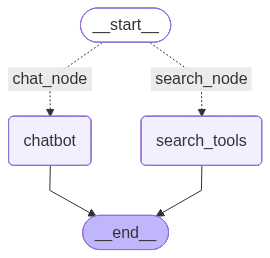



🔵 === 测试 1: 什么是 Milvus (应该触发搜索) ===

--- 🚦 正在路由分类 ---
DEBUG: 模型判断结果 -> 'SEARCH'
--- 🔍 进入真实 Milvus 搜索 ---
DEBUG: 检索关键词 -> Milvus 是什么数据库？
【数据库检索结果】:
[1] (相似度 0.79): Milvus 是一个云原生的开源向量数据库。
[2] (相似度 0.36): Zilliz Cloud 提供了全托管服务。
[3] (相似度 0.29): Python 是一种广泛用于 AI 的语言。


🟢 === 测试 2: 简单问候 (应该触发闲聊) ===

--- 🚦 正在路由分类 ---
DEBUG: 模型判断结果 -> 'CHAT'
--- 💬 进入闲聊模式 ---
你好！我是你的 AI 助手。刚才我们进行了一次愉快的闲聊。有什么我可以帮你的吗？


In [ ]:
import os
from typing import TypedDict, Annotated, List

# LangChain / LangGraph imports
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage
from langchain_huggingface import HuggingFaceEmbeddings

# Milvus imports
from pymilvus import MilvusClient

# Visualization imports
from IPython.display import Image, display

# 1. 准备 Embedding 模型
print("🔌 正在加载 Embedding 模型 (本地 BGE)...")
embeddings = HuggingFaceEmbeddings(
    model_name="D:/ollama/bge-base-zh-v1.5",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

# 2. 连接 Milvus 数据库
ZILLIZ_URI = "https://in03-f410f8aefc6d1ee.serverless.gcp-us-west1.cloud.zilliz.com"
ZILLIZ_TOKEN = os.getenv("ZILLIZ_TOKEN")
COLLECTION_NAME = "bge_test_new_api" # 你的表名

if not ZILLIZ_TOKEN:
    raise ValueError("❌ 未找到环境变量 'ZILLIZ_TOKEN'，请检查 .env 文件！")

print(f"🔌 正在连接 Milvus Cloud ({COLLECTION_NAME})...")
client = MilvusClient(uri=ZILLIZ_URI, token=ZILLIZ_TOKEN)

# 3. 初始化 LLM
llm = ChatOllama(model="gemma3:4b", temperature=0)

# ==========================================
# 1. 定义状态 (State)
# ==========================================
class AgentState(TypedDict):
    messages: Annotated[List, add_messages]

# ==========================================
# 2. 定义路由节点 (Router Node)
# ==========================================
ROUTER_PROMPT = """
你是一个流程分类器。你需要分析用户的意图。
只能输出下面两个单词中的一个，严禁输出其他任何内容：
- SEARCH (如果用户想查询技术文档、数据库知识、Python、天气、或者具体的实体定义)
- CHAT (如果用户只是闲聊、打招呼、问好)

用户输入: {input}
分类结果:
"""

def router_node(state: AgentState):
    print("\n--- 🚦 正在路由分类 ---")
    last_message = state["messages"][-1].content
    
    # 调用 LLM
    response = llm.invoke(ROUTER_PROMPT.format(input=last_message))
    
    # 👇 修复逻辑: 处理可能的列表返回类型
    raw_content = response.content
    if isinstance(raw_content, list):
        text_content = "".join([str(item) for item in raw_content])
    else:
        text_content = str(raw_content)
        
    content = text_content.strip().upper()
    print(f"DEBUG: 模型判断结果 -> '{content}'")
    
    if "SEARCH" in content:
        return "search_node"
    else:
        return "chat_node"


# ==========================================
# 3. 定义执行节点 (Worker Nodes)
# ==========================================

def chat_node(state: AgentState):
    print("--- 💬 进入闲聊模式 ---")
    return {"messages": [AIMessage(content="你好！我是你的 AI 助手。刚才我们进行了一次愉快的闲聊。有什么我可以帮你的吗？")]}

def search_node(state: AgentState):
    print("--- 🔍 进入真实 Milvus 搜索 ---")
    
    user_query = state["messages"][-1].content
    print(f"DEBUG: 检索关键词 -> {user_query}")
    
    try:
        # 1. 生成向量
        query_vector = embeddings.embed_query(user_query)
        
        # 2. 数据库检索
        search_res = client.search(
            collection_name=COLLECTION_NAME,
            data=[query_vector],
            limit=3,
            output_fields=["text"],
            search_params={"metric_type": "COSINE", "params": {}}
        )
        
        # 3. 格式化结果
        if not search_res or not search_res[0]:
            result_text = "数据库中没有找到相关信息。"
        else:
            # 提取 text 字段并拼接
            found_texts = []
            for i, hit in enumerate(search_res[0]):
                score = hit['distance']
                text = hit['entity']['text']
                found_texts.append(f"[{i+1}] (相似度 {score:.2f}): {text}")
            
            result_text = "\n".join(found_texts)
            
        final_response = f"【数据库检索结果】:\n{result_text}"
        
    except Exception as e:
        final_response = f"❌ 检索出错: {str(e)}"
        print(final_response)

    return {"messages": [AIMessage(content=final_response)]}


# ==========================================
# 4. 构建图 (Graph Construction)
# ==========================================
workflow = StateGraph(AgentState)

# 添加节点
workflow.add_node("chatbot", chat_node)
workflow.add_node("search_tools", search_node)

# 添加条件路由
workflow.add_conditional_edges(
    START,
    router_node,
    {
        "search_node": "search_tools",
        "chat_node": "chatbot"
    }
)

# 添加结束边
workflow.add_edge("chatbot", END)
workflow.add_edge("search_tools", END)

# 编译
app = workflow.compile()

# 可视化 (如果安装了 graphviz 可能会显示图片，否则跳过)
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass


# ==========================================
# 5. 运行测试
# ==========================================

print("\n\n🔵 === 测试 1: 什么是 Milvus (应该触发搜索) ===")
# 期望：Router -> SEARCH -> search_node -> 查库返回
res1 = app.invoke({"messages": [HumanMessage(content="Milvus 是什么数据库？")]})
print(res1['messages'][-1].content)

print("\n\n🟢 === 测试 2: 简单问候 (应该触发闲聊) ===")
# 期望：Router -> CHAT -> chat_node -> 静态回复
res2 = app.invoke({"messages": [HumanMessage(content="嗨，早上好")]})
print(res2['messages'][-1].content)